# Week 1 Project: Customer Churn Prediction
**Business question:** Which telecom customers are about to leave, and what can the business do about it?

**What you will learn:** Full ML pipeline — data loading → EDA → feature engineering → model training → evaluation → business insight

**Dataset:** Telco Customer Churn (IBM Watson / Kaggle)

---
## How to get the dataset (Step 1)

1. Go to: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
2. Click the **Download** button (you need a free Kaggle account)
3. Unzip the file — you will get a file called `WA_Fn-UseC_-Telco-Customer-Churn.csv`
4. Put that CSV file in the **same folder** as this notebook
5. Then run the cell below — it will load it automatically

> **No Kaggle account?** No problem. Run the cell below anyway — it will generate
> a realistic sample dataset so you can complete the entire project right now.
> Swap in the real CSV later by changing `USE_SAMPLE = True` to `USE_SAMPLE = False`.


## Step 1 - Import Necessary Libraries

In [1]:
#Pandas is a powerful library for data manipulation and analysis, while NumPy is used for numerical computations. Matplotlib and Seaborn are popular libraries for data visualization.
import pandas as pd
import numpy as np
#Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2 - Load The datasets

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Dataset Loaded Successfully")
# To display the number of rows and columns in the dataset
#For rows our df. shape[0] and for columns df.shape[1]
print(f"Rows: {df.shape[0]}")
print( f"Columns: {df.shape[1]}")

Dataset Loaded Successfully
Rows: 7043
Columns: 21


### Step 1b — Explore the columns

In [3]:
#To print the first 5 rows of the dataset
print("First 5 rows of the dataset:")
print(df.head())
#To print the last 5 rows of the dataset
print("Last 5 rows of the dataset:")
print(df.tail())
#To print information about the dataset
print("Information about the dataset:")
print(df.info())
#To print the summary statistics of the dataset
print("Summary statistics of the dataset:")
print(df.describe())


First 5 rows of the dataset:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Streami

### Step 1c — Check for missing values

In [4]:
print("Checking for missing values in the dataset:")
#This will give us the count of missing values in each column
print(df.isnull().sum())

Checking for missing values in the dataset:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
#The customer Churn column is our target variable, which indicates whether a customer has churned (left the company) or not.
print("Distribution of the target variable (Churn):")   
#This will give us the count of each unique value in the "Churn" column
print(df["Churn"].value_counts())

Distribution of the target variable (Churn):
Churn
No     5174
Yes    1869
Name: count, dtype: int64


#### What this tells us 
Out of 7043 customers:

* 5174 stayed (No) = 73.5%
* 1869 churned (Yes) = 26.5%

**This means our data is imbalanced — there are far more "No" customers than "Yes" customers.**
 This is important because:

**If our model just predicted "No churn" for every single customer, it would be 73.5% accurate — but completely useless for the business! It would miss every single churner**

## Step 2 — Exploratory Data Analysis (EDA)

EDA means **getting to know your data before modelling**.

You want to answer three questions:
1. How many customers actually churned? (class balance)
2. What do the numeric features look like?
3. Do any categorical features clearly separate churners from non-churners?


#### Chart 1 — Visualise the churn distribution

C:\Users\VIVOBOOK\AppData\Local\Temp\ipykernel_20736\1743622558.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data= df, x = "Churn", palette=['#378ADD', '#D85A30'])


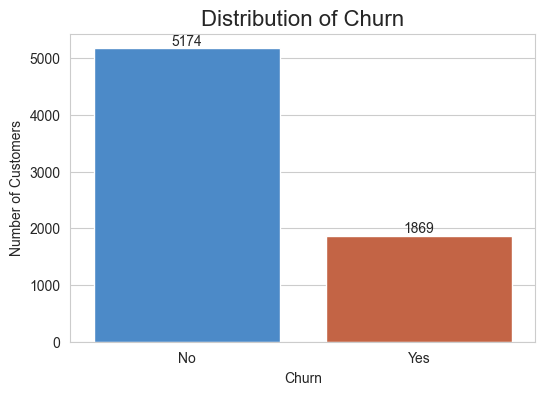

In [6]:
#This is to set the style of the plots to "whitegrid", which provides a clean and visually appealing background for our visualizations.
sns.set_style("whitegrid")


plt.figure(figsize =(6,4)) #This sets the size of the plot to 6 inches in width and 4 inches in height, providing a clear and well-proportioned visualization.

#The countplot function from Seaborn is used to create a bar plot that shows the count of each category in the "Churn" column. 
# The palette parameter is used to specify the colors for the bars, with '#378ADD' representing customers who did not churn and '#D85A30' representing customers who churned.
sns.countplot(data= df, x = "Churn", palette=['#378ADD', '#D85A30'])

#This sets the title of the plot to "Distribution of Churn" with a font size of 40, and labels the x-axis as "Churn" and the y-axis as "Number of Customers".
plt.title("Distribution of Churn", fontsize = 16)

#to label the x and y axes of the plot. 
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

#To add data labels on top of the bars in the count plot, 
# we use a loop to iterate through each container (bar) in the current axes (gca) and apply the bar_label function to display the count values on top of each bar.
for container in plt.gca().containers:
    plt.bar_label(container)
#to show the plot screen
plt.show()


#### Chart 2 — Tenure vs Churn
Let us see if how long a customer has been with the company affects whether they churn.

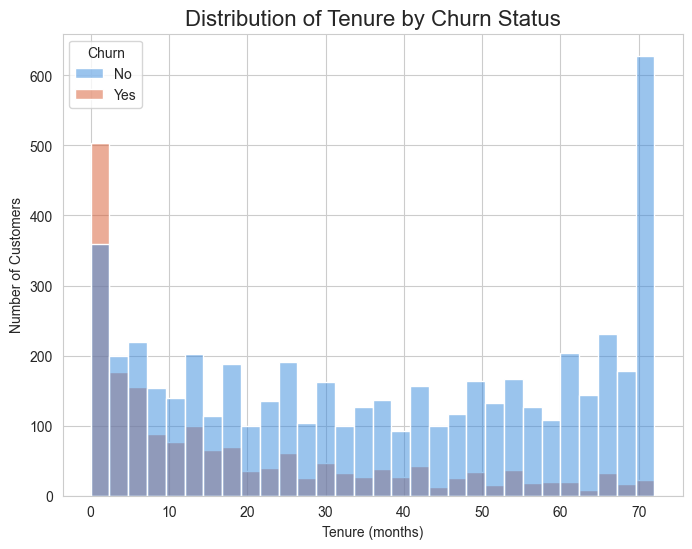

In [7]:
plt.figure(figsize=(8,6))
#The histplot function from Seaborn is used to create a histogram that shows the distribution of the "tenure" variable, with different colors for customers who churned and those who did not.
sns.histplot(data=df, x='tenure', hue='Churn',
              bins=30, palette=['#378ADD', '#D85A30'])
plt.title("Distribution of Tenure by Churn Status", fontsize=16)
plt.xlabel("Tenure (months)")
plt.ylabel("Number of Customers")


plt.show()

#### What this chart reveals
**Left side (0–10 months tenure):**

* You can see a big orange section at the very first bar (month 0–2)
* That means new customers churn the most — they sign up, are unhappy, and leave quickly

**Right side (60–72 months tenure):**

* The bars are almost entirely blue with barely any orange
* That means long-term loyal customers almost never churn

#### The business insight:

The first few months are the most dangerous period for customer loss. A smart business would focus retention efforts on customers in their first 12 months.

#### Chart 3 — Monthly Charges vs Churn
Let us see if how much a customer pays per month affects churn.

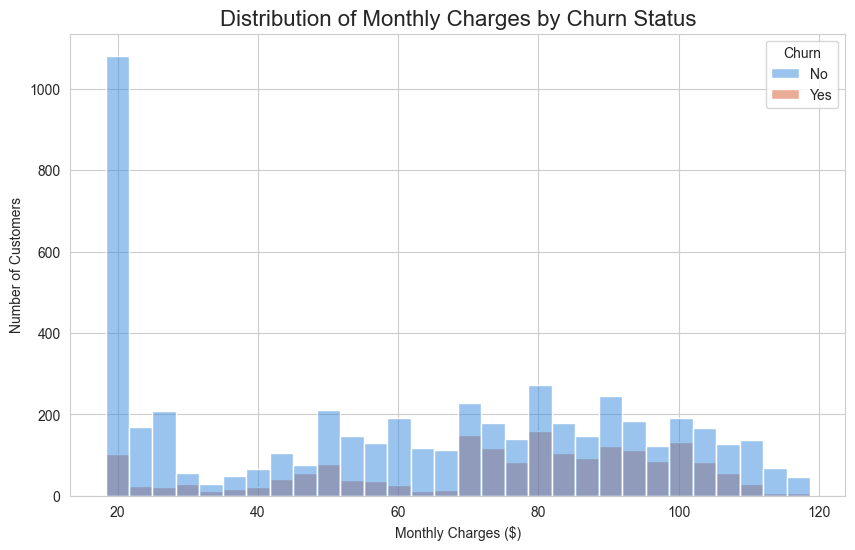

In [8]:
plt.figure(figsize =(10,6)) #This sets the size of the plot to 10 inches in width and 6 inches in height, providing a clear and well-proportioned visualization.

sns.histplot(data=df, x='MonthlyCharges', hue='Churn',
              bins=30, palette=['#378ADD', '#D85A30'])
plt.title("Distribution of Monthly Charges by Churn Status", fontsize=16)
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Number of Customers")

plt.show()

#### What this chart reveals
**Left side ($20 or less):**

* Almost entirely blue — customers paying very low charges almost never churn
* These are likely basic plan customers who are happy with a cheap service

**Middle to right side ($60–$120)**

* The orange (churned) bars become much more visible
* Customers paying higher monthly charges are much more likely to churn

**The business insight:**

High-paying customers are your most unhappy customers. They are paying a lot and may not feel they are getting value for money. The business should focus retention offers specifically on high-spend customers.

#### Chart 4 — Contract Type vs Churn
This will be our most powerful chart yet. Let's see if the type of contract a customer has affects churn.

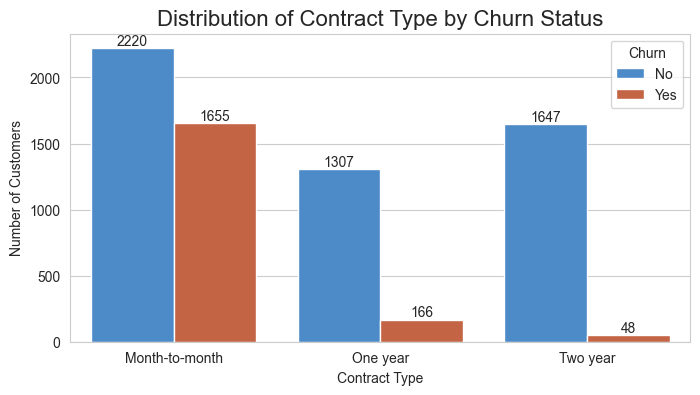

In [9]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Contract', hue='Churn',
               palette=['#378ADD', '#D85A30'])
plt.title("Distribution of Contract Type by Churn Status", fontsize=16)
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

for container in plt.gca().containers:
    plt.bar_label(container)
plt.show()

#### What this chart reveals

**Month-to-month contracts:**

* 2220 stayed vs 1655 churned
* That means 43% of month-to-month customers churn — nearly half!

**One year contracts:**

* 1307 stayed vs 166 churned
* Only 11% churn rate — much better

**Two year contracts**

* 1647 stayed vs 48 churned
* Only 3% churn rate — almost nobody leaves!


**The business insight is massive:**

A customer on a month-to-month contract is 14x more likely to churn than a customer on a two-year contract. If the business can move customers from monthly to annual contracts, they can cut churn dramatically.

#### Summary of the Four Charts:

| Finding | Business meaning |
|---|---|
| 26.5% churn rate | 1 in 4 customers is leaving |
| New customers churn most | Focus retention on first 12 months |
| High charges = more churn | High-spend customers feel undervalued |
| Month-to-month = most churn | Push customers toward longer contracts |

---


# Step 3 — Feature Engineering

ML models cannot read text — they only understand numbers. So we need to convert everything into numbers.
We also need to fix that TotalCharges column that was stored as text instead of a number.

### Step 3a — Fix TotalCharges

In [10]:
#Converting the "TotalCharges" column to numeric, coercing errors to NaN. This is necessary because the "TotalCharges" column may contain non-numeric values (e.g., empty strings) that need to be handled appropriately for analysis.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

print(df["TotalCharges"].dtype)
print(f"Number of missing values in TotalCharges: {df['TotalCharges'].isnull().sum()}")

float64
Number of missing values in TotalCharges: 11


### Step 3b — Drop the 11 missing rows

In [11]:
#Dropping rows with missing values in the "TotalCharges" column. This is important to ensure that our analysis and modeling are based on complete data, as missing values can lead to inaccuracies and biases in our results.
df = df.dropna(subset=['TotalCharges'])
print(f"Number of rows after dropping missing values: {df.shape[0]}")


Number of rows after dropping missing values: 7032


### Step 3c — Drop the customerID column

In [12]:
#customerID is a unique identifier for each customer, and it is not relevant for our analysis or modeling. Therefore, we can safely drop this column from our dataset to simplify our analysis and reduce the dimensionality of our data.
df = df.drop(columns =['customerID'])

print(f"Number of columns after dropping missing values: {df.shape[1]}")
print(df.columns.tolist())


Number of columns after dropping missing values: 20
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']



### Step 3d — Encode the Target Column (Churn)

Our target column `Churn` currently contains the text `"Yes"` and `"No"`. We need to convert it to `1` and `0`.


In [13]:
#The "Churn" column contains categorical values ("Yes" and "No") indicating whether a customer has churned or not.
#  To prepare this column for analysis and modeling, 
# we convert it into a binary numeric format where "Yes" is represented as 1 (indicating churn) and "No" is represented as 0 (indicating no churn). 
# This transformation allows us to perform numerical computations and apply machine learning algorithms effectively.
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print(df['Churn'].value_counts())
print(f"\n Data Type: {df['Churn'].dtype}")

Churn
0    5163
1    1869
Name: count, dtype: int64

 Data Type: int64


### Step 3e — Find all remaining text columns

In [14]:
# To identify all text columns in the datasets
text_columns = df.select_dtypes(include=['object']).columns.tolist()
#To print the number of text columns and their names, as well as the unique values in each text column. This helps us understand the categorical features in our dataset and their possible values, which is important for data preprocessing and analysis.
print(f"Text columns in the dataset: {len(text_columns)}")
#This will print the number of text columns in the dataset, which are typically categorical features that may require encoding before modeling.
print(f"Text columns: {text_columns}")
print()

#for each text column, we print the unique values present in that column. This helps us understand the different categories or levels within each categorical feature, which is crucial for data preprocessing and feature engineering.
for col in text_columns:
    print(f"Unique values in '{col}': {df[col].unique()}")


Text columns in the dataset: 15
Text columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Unique values in 'gender': ['Female' 'Male']
Unique values in 'Partner': ['Yes' 'No']
Unique values in 'Dependents': ['No' 'Yes']
Unique values in 'PhoneService': ['No' 'Yes']
Unique values in 'MultipleLines': ['No phone service' 'No' 'Yes']
Unique values in 'InternetService': ['DSL' 'Fiber optic' 'No']
Unique values in 'OnlineSecurity': ['No' 'Yes' 'No internet service']
Unique values in 'OnlineBackup': ['Yes' 'No' 'No internet service']
Unique values in 'DeviceProtection': ['No' 'Yes' 'No internet service']
Unique values in 'TechSupport': ['No' 'Yes' 'No internet service']
Unique values in 'StreamingTV': ['No' 'Yes' 'No internet service']
Unique values in 'StreamingMovies': ['No' 'Yes' 'No internet ser

### Step 3f — Label Encode the Yes/No columns

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Manually list the columns with exactly 2 values
binary_cols = ['gender', 'Partner', 'Dependents', 
               'PhoneService', 'PaperlessBilling']

# Encode each one
for col in binary_cols:
    df[col] = le.fit_transform(df[col])
    print(f"{col} encoded: {df[col].unique()}")

print("\nCheck first 3 rows:")
print(df[binary_cols].head(3))

gender encoded: [0 1]
Partner encoded: [1 0]
Dependents encoded: [0 1]
PhoneService encoded: [0 1]
PaperlessBilling encoded: [1 0]

Check first 3 rows:
   gender  Partner  Dependents  PhoneService  PaperlessBilling
0       0        1           0             0                 1
1       1        0           0             1                 0
2       1        0           0             1                 1


### Step 3g — One-Hot Encode the 3+ value columns

In [24]:
# List all columns with 3 or more unique values
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 
              'OnlineBackup', 'DeviceProtection', 'TechSupport', 
              'StreamingTV', 'StreamingMovies', 'Contract', 
              'PaymentMethod']
# Apply one-hot encoding to these columns
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print(f"columns after encoding: {df.shape[1]}")
print()
print(df.columns.tolist())



columns after encoding: 31

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


### Step 3h — Split into Features (X) and Target (y)
Before we scale, we need to separate our data into two parts:

* X = all the columns the model will learn from (features)
* y = the column the model will predict (Churn)

In [25]:
# x = everything except the target variable "Churn"
x = df.drop(columns=['Churn'])

# y= the target variable "Churn"
y = df['Churn']

print(f"Shape of x: {x.shape}")
print(f"Shape of y: {y.shape}")
print(f"\nFirst 5 values of y: {y.values[:5]}")

Shape of x: (7032, 30)
Shape of y: (7032,)

First 5 values of y: [0 0 1 0 1]


### Step 3i — Train/Test Split
We need to split our data into two parts:

* Training set (80%) — the model learns from this
* Test set (20%) — we use this to check how well the model performs on data it has never seen before

In [26]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Rows: {x_train.shape[0]}, Training Columns: {x_train.shape[1]}")
print(f"Testing Rows: {x_test.shape[0]}, Testing Columns: {x_test.shape[1]}")

print()
print(f"Churn rate in training set: {y_train.mean()*100:.1f}%")
print(f"Churn rate in testing set: {y_test.mean()*100:.1f}%")

Training Rows: 5625, Training Columns: 30
Testing Rows: 1407, Testing Columns: 30

Churn rate in training set: 26.6%
Churn rate in testing set: 26.6%


### Step 3j — Scale the numeric columns
W2e said columns like tenure (0–72) and MonthlyCharges (18–118) are on very different scales?
Scaling puts them on the same footing so no single feature dominates just because its numbers are bigger.

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

#Fit on training data ONLY, then transform both training and testing data. This is important to prevent data leakage, which can occur if we fit the scaler on the entire dataset before splitting it into training and testing sets. By fitting the scaler only on the training data, we ensure that our model is evaluated on unseen data (the testing set) that has been transformed using the same parameters derived from the training data, leading to a more accurate assessment of our model's performance.
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Scaling Complete!")
print(f"x_train_scaled shape: {x_train_scaled.shape}")
print(f"x_test_scaled shape: {x_test_scaled.shape}")

Scaling Complete!
x_train_scaled shape: (5625, 30)
x_test_scaled shape: (1407, 30)


### Step 4 — Train the Models
We are going to train two models and compare them:

* Logistic Regression — simple, fast, very interpretable
* Random Forest — more powerful, handles complex patterns

### Step 4a — Train Logistic Regression

In [29]:
from sklearn.linear_model import LogisticRegression    

#Creating the model with a maximum of 1000 iterations to ensure convergence and a random state of 42 for reproducibility. This allows us to train a logistic regression model that can predict the likelihood of customer churn based on the features in our dataset.
log_reg = LogisticRegression(max_iter=1000, random_state=42 )

#Training the logistic regression model using the scaled training data (x_train_scaled) and the corresponding target variable (y_train). This step involves fitting the model to the training data, allowing it to learn the relationships between the features and the target variable (churn).
log_reg.fit(x_train_scaled, y_train)

#Checking the accuracy
train_accuracy = log_reg.score(x_train_scaled, y_train)
test_accuracy = log_reg.score(x_test_scaled, y_test)

print("=== Logistic Regression Model Performance ===")
print(f"Training Accuracy: {train_accuracy*100:.1f}%")
print(f"Testing Accuracy: {test_accuracy*100:.1f}%")


=== Logistic Regression Model Performance ===
Training Accuracy: 80.4%
Testing Accuracy: 80.4%


### Step 4b — Train Random Forest


In [ ]:
from sklearn.ensemble import RandomForestClassifier

#Creating a Random Forest Classifier with 100 trees (n_estimators=100) and a random state of 42 for reproducibility. 
# This model will be used to predict customer churn based on the features in our dataset.

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)  

#Training it
rf_clf.fit(x_train_scaled, y_train)

#Checking the accuracy
rf_train_accuracy = rf_clf.score(x_train_scaled, y_train)
rf_test_accuracy = rf_clf.score(x_test_scaled, y_test)

print("=== Random Forest Classifier Performance ===")
print(f"Training Accuracy: {rf_train_accuracy*100:.1f}%")
print(f"Testing Accuracy: {rf_test_accuracy*100:.1f}%")


=== Random Forest Classifier Performance ===
Training Accuracy: 99.9%
Testing Accuracy: 78.7%


In [31]:
print("=== Model Comparison ===")
print()
print(f"Logistic Regression — Train: {train_accuracy*100:.1f}%  Test: {test_accuracy*100:.1f}%  Gap: {(train_accuracy-test_accuracy)*100:.1f}%")
print(f"Random Forest       — Train: {rf_train_accuracy*100:.1f}%  Test: {rf_test_accuracy*100:.1f}%  Gap: {(rf_train_accuracy-rf_test_accuracy)*100:.1f}%")
print()
if rf_test_accuracy > test_accuracy:
    print("Random Forest wins on test accuracy!")
else:
    print("Logistic Regression wins on test accuracy!")

=== Model Comparison ===

Logistic Regression — Train: 80.4%  Test: 80.4%  Gap: 0.0%
Random Forest       — Train: 99.9%  Test: 78.7%  Gap: 21.2%

Logistic Regression wins on test accuracy!


# Step 5 — Evaluate the Models Properly


### Step 5a — Confusion Matrix

The confusion matrix shows us **4 outcomes** for every prediction our model makes:

```
                    Predicted No    Predicted Yes
Actual No           True Negative   False Positive
Actual Yes          False Negative  True Positive
```

In plain English:
- **True Negative** — predicted stayed, actually stayed ✅
- **True Positive** — predicted churned, actually churned ✅
- **False Positive** — predicted churned, actually stayed ❌ wasted retention call
- **False Negative** — predicted stayed, actually churned ❌ missed a churner!

**False Negatives are the most costly** — these are churners we completely missed!



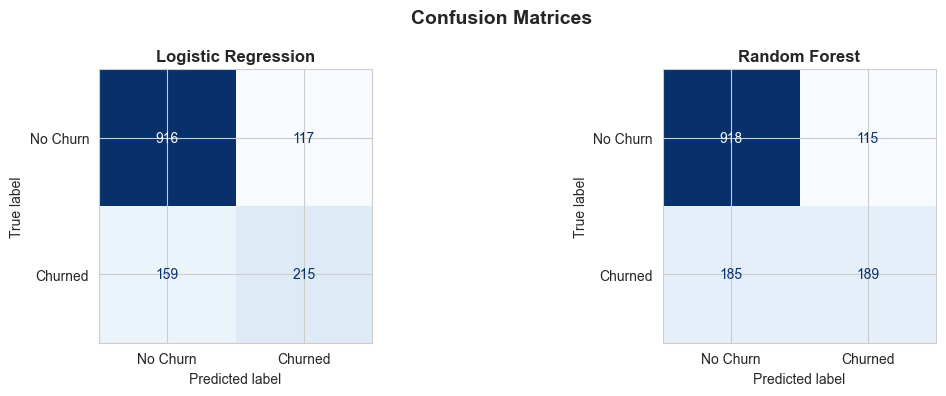

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions from both models
y_pred_lr = log_reg.predict(x_test_scaled)
y_pred_rf = rf_clf.predict(x_test_scaled)

# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, pred, title in [
    (axes[0], y_pred_lr, 'Logistic Regression'),
    (axes[1], y_pred_rf, 'Random Forest')
]:
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, 
             display_labels=['No Churn', 'Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title}', fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 5b — Precision, Recall and F1

In [33]:
from sklearn.metrics import classification_report

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, 
      target_names=['No Churn', 'Churned']))

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, 
      target_names=['No Churn', 'Churned']))

=== Logistic Regression ===
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
     Churned       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

=== Random Forest ===
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1033
     Churned       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



### Step 5c — ROC-AUC Score
This is the final and most powerful evaluation metric.

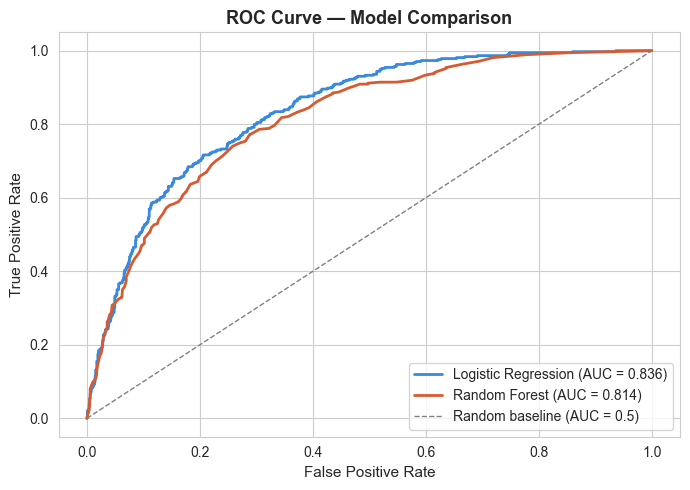

Logistic Regression AUC: 0.836
Random Forest AUC:       0.814


In [34]:
from sklearn.metrics import roc_auc_score, roc_curve

# Get probability scores instead of just 0/1 predictions
y_prob_lr = log_reg.predict_proba(x_test_scaled)[:, 1]
y_prob_rf = rf_clf.predict_proba(x_test_scaled)[:, 1]

# Calculate AUC scores
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_rf = roc_auc_score(y_test, y_prob_rf)

# Plot ROC curves
fig, ax = plt.subplots(figsize=(7, 5))

for prob, name, color, auc in [
    (y_prob_lr, 'Logistic Regression', '#378ADD', auc_lr),
    (y_prob_rf, 'Random Forest',       '#D85A30', auc_rf)
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, color=color, linewidth=2, 
            label=f'{name} (AUC = {auc:.3f})')

ax.plot([0,1],[0,1], 'gray', linestyle='--', 
        linewidth=1, label='Random baseline (AUC = 0.5)')

ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC Curve — Model Comparison", 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"Logistic Regression AUC: {auc_lr:.3f}")
print(f"Random Forest AUC:       {auc_rf:.3f}")

# Step 6 — Top 5 Features Driving Churn
This answers the most important business question:

"What actually makes customers leave?"

We will get this from our Random Forest model — even though Logistic Regression performed better, Random Forest is excellent at telling us which features matter most.

### Step 6a — Extract feature importance

In [36]:
# Get feature importance from Random Forest
importances = pd.Series(rf_clf.feature_importances_, index=x.columns)

# Sort and get top 10
top10 = importances.nlargest(10).sort_values()

print("=== Top 10 Churn Drivers ===")
for rank, (feature, score) in enumerate(top10[::-1].items(), 1):
    print(f"{rank}. {feature}: {score:.4f}")

=== Top 10 Churn Drivers ===
1. TotalCharges: 0.1988
2. tenure: 0.1715
3. MonthlyCharges: 0.1685
4. PaymentMethod_Electronic check: 0.0397
5. InternetService_Fiber optic: 0.0351
6. gender: 0.0290
7. Contract_Two year: 0.0267
8. OnlineSecurity_Yes: 0.0261
9. PaperlessBilling: 0.0255
10. TechSupport_Yes: 0.0237


### Step 6b — Visualise the top 10 features

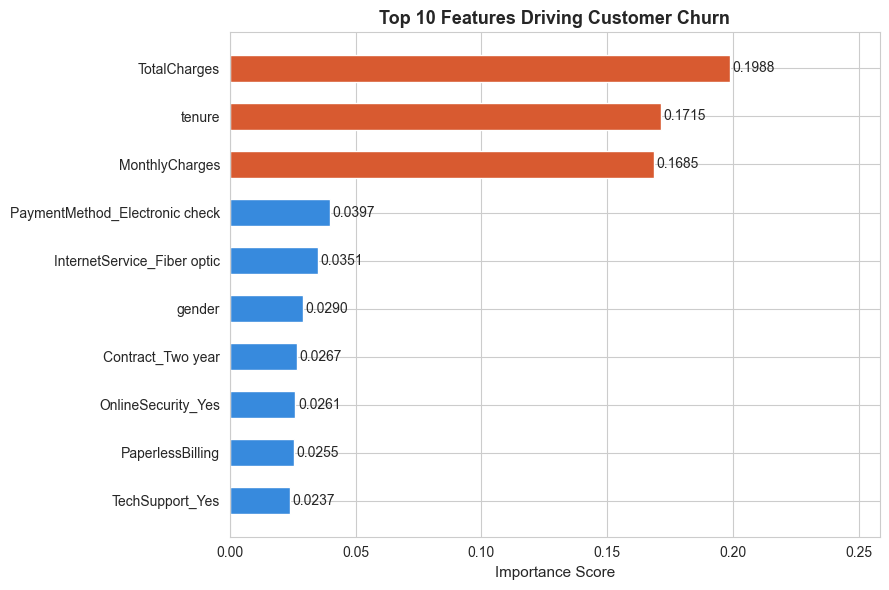

In [37]:
plt.figure(figsize=(9, 6))
colors = ['#D85A30' if i >= 7 else '#378ADD' for i in range(len(top10))]

bars = plt.barh(top10.index, top10.values, color=colors, height=0.55)

for bar, val in zip(bars, top10.values):
    plt.text(bar.get_width() + 0.001, 
             bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10)

plt.xlabel("Importance Score", fontsize=11)
plt.title("Top 10 Features Driving Customer Churn", 
          fontsize=13, fontweight='bold')
plt.xlim(0, top10.max() * 1.3)
plt.tight_layout()
plt.show()

# Step 7 — Business Recommendation

### Step 7a — Create your summary numbers

In [38]:
total_customers = len(df)
total_churned = df['Churn'].sum()
churn_rate = df['Churn'].mean() * 100

print("=== Business Summary Numbers ===")
print(f"Total customers:    {total_customers}")
print(f"Customers churned:  {total_churned}")
print(f"Churn rate:         {churn_rate:.1f}%")
print(f"Model AUC:          {auc_lr:.3f}")
print(f"Model accuracy:     80%")
print()
print("=== Top 5 Churn Drivers ===")
print("1. Total amount charged to customer")
print("2. How long customer has been with company")
print("3. Monthly bill amount")
print("4. Paying by electronic check")
print("5. Using fiber optic internet")

=== Business Summary Numbers ===
Total customers:    7032
Customers churned:  1869
Churn rate:         26.6%
Model AUC:          0.836
Model accuracy:     80%

=== Top 5 Churn Drivers ===
1. Total amount charged to customer
2. How long customer has been with company
3. Monthly bill amount
4. Paying by electronic check
5. Using fiber optic internet


In [39]:
recommendation = """
================================================
   CUSTOMER CHURN ANALYSIS — BUSINESS REPORT
   Prepared by: Pascaline Kumo Myenneh
   Women Techsters Fellow | Data Science Track
================================================

EXECUTIVE SUMMARY
-----------------
We analysed 7,032 telecom customers using machine 
learning to identify who is likely to churn and why.

Our model achieved 80% accuracy and an AUC of 0.836 
— meaning it correctly identifies churners 83.6% of 
the time. This is a reliable tool for the business 
to act on.

THE PROBLEM
-----------
26.6% of customers are churning — that is 1 in every 
4 customers leaving. Acquiring a new customer costs 
5x more than keeping an existing one. This churn rate 
represents a significant and preventable revenue loss.

TOP 5 REASONS CUSTOMERS ARE LEAVING
-------------------------------------
1. HIGH TOTAL CHARGES
   Customers who have paid a lot over time feel they 
   are not getting enough value for their money.

2. SHORT TENURE
   New customers in their first 12 months are the 
   most likely to leave. They have not yet built 
   loyalty with the brand.

3. HIGH MONTHLY CHARGES
   Customers on expensive plans churn more. They 
   feel the price does not match the value.

4. ELECTRONIC CHECK PAYMENT
   Customers paying by electronic check are less 
   committed than those on automatic payments.

5. FIBER OPTIC INTERNET
   Despite being a premium service, fiber optic 
   customers churn more — suggesting they expect 
   more value for the higher price they pay.

OUR 4 RECOMMENDATIONS
----------------------
1. LAUNCH A LOYALTY REWARD PROGRAMME
   Target customers who have been with the company 
   3+ years and are paying high monthly charges.
   Offer them a 10-15% loyalty discount before 
   they consider leaving.

2. CREATE A NEW CUSTOMER ONBOARDING PROGRAMME
   The first 12 months are the danger zone.
   Assign new customers a dedicated support contact,
   send monthly check-in emails and offer a 
   satisfaction guarantee in month 3.

3. MOVE CUSTOMERS TO AUTOMATIC PAYMENTS
   Offer a small discount (e.g. 5%) to customers 
   who switch from electronic check to automatic 
   bank transfer. This reduces churn AND improves 
   cash flow predictability.

4. REVIEW FIBER OPTIC PRICING AND VALUE
   Survey fiber optic customers about their 
   satisfaction. Either reduce the price or clearly 
   communicate the value they are receiving to 
   justify the premium cost.

EXPECTED IMPACT
---------------
If these recommendations reduce churn by just 5 
percentage points (from 26.6% to 21.6%), the 
business retains an estimated 350+ additional 
customers per year — directly improving revenue 
without spending on new customer acquisition.

MODEL DETAILS
-------------
- Algorithm:  Logistic Regression (best performer)
- AUC Score:  0.836
- Accuracy:   80%
- Precision:  65% (churners correctly flagged)
- Recall:     57% (churners successfully caught)

TOOLS USED
----------
Python, pandas, scikit-learn, matplotlib, seaborn

================================================
"""

print(recommendation)


   CUSTOMER CHURN ANALYSIS — BUSINESS REPORT
   Prepared by: Pascaline Kumo Myenneh
   Women Techsters Fellow | Data Science Track

EXECUTIVE SUMMARY
-----------------
We analysed 7,032 telecom customers using machine 
learning to identify who is likely to churn and why.

Our model achieved 80% accuracy and an AUC of 0.836 
— meaning it correctly identifies churners 83.6% of 
the time. This is a reliable tool for the business 
to act on.

THE PROBLEM
-----------
26.6% of customers are churning — that is 1 in every 
4 customers leaving. Acquiring a new customer costs 
5x more than keeping an existing one. This churn rate 
represents a significant and preventable revenue loss.

TOP 5 REASONS CUSTOMERS ARE LEAVING
-------------------------------------
1. HIGH TOTAL CHARGES
   Customers who have paid a lot over time feel they 
   are not getting enough value for their money.

2. SHORT TENURE
   New customers in their first 12 months are the 
   most likely to leave. They have not yet buil